In [1]:
!wget https://www.lamsade.dauphine.fr/~cazenave/project2025.zip
!unzip project2025.zip
!ls -l

!pip uninstall -y tensorflow
!pip install tensorrt-bindings==8.6.1
!pip install --extra-index-url https://pypi.nvidia.com tensorrt-libs
!pip install tensorflow[and-cuda]==2.15.0

# redemarrer la session

--2025-05-12 16:52:37--  https://www.lamsade.dauphine.fr/~cazenave/project2025.zip
Resolving www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)... 193.48.71.250
Connecting to www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)|193.48.71.250|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 486727746 (464M) [application/zip]
Saving to: ‘project2025.zip’

project2025.zip     100%[===================>] 464.18M  19.3MB/s    in 26s     

2025-05-12 16:53:04 (18.1 MB/s) - ‘project2025.zip’ saved [486727746/486727746]

Archive:  project2025.zip
  inflating: games2022.data          
  inflating: Golois.cpython-310-x86_64-linux-gnu.so  
  inflating: Golois.cpython-38-x86_64-linux-gnu.so  
  inflating: golois.cpython-310-x86_64-linux-gnu.so  
  inflating: golois.cpython-311-x86_64-linux-gnu.so  
  inflating: golois.cpython-37m-x86_64-linux-gnu.so  
  inflating: golois.cpython-38-x86_64-linux-gnu.so  
  inflating: trainGolois.py          
total 2382016
-rw-r--r-- 1 root root 

# 1. Models

In [7]:
from tensorflow import keras
from keras.models import Model
from keras import regularizers
from keras.layers import (
    Input, Dense, Conv2D, GlobalAveragePooling2D, Dropout, Flatten,
    Activation, BatchNormalization, Add, Reshape, DepthwiseConv2D, Multiply,
    AveragePooling2D, Concatenate
)
from keras.layers import Conv2D, DepthwiseConv2D, Dense, GlobalAveragePooling2D, Concatenate
from keras.layers import Activation, BatchNormalization, Add, Multiply, Reshape

class GoBaseNet:

    def __init__(self, shape, n_class):
        self.shape = shape
        self.n_class = n_class

    def _conv_block(self, inputs, filters, kernel, activation=None):
        x = Conv2D(filters, kernel, padding='same', kernel_regularizer=regularizers.l2(0.0001),
               use_bias=False, kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
        return x

    def _depthwise_conv_block(self, inputs, kernel, activation):
        x = DepthwiseConv2D(kernel, depth_multiplier=1, padding='same', use_bias=False,
                        kernel_regularizer=regularizers.l2(0.0001),
                        kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation(activation)(x)
        return x

    def _squeeze_block(self, input, ratio=16):
        filters = input.shape[-1]
        se = GlobalAveragePooling2D()(input)
        se = Reshape((1, 1, filters))(se)
        se = Dense(filters // ratio, activation='relu', use_bias=False)(se)
        se = Dense(filters, activation='sigmoid', use_bias=False)(se)
        x = Multiply()([input, se])
        return x

    def _bottleneck_block(self, inputs, filters, kernel, factor, squeeze, activation):
        expension = int(filters * factor)
        x = self._conv_block(inputs, expension, (1, 1), activation)
        x = self._depthwise_conv_block(x, kernel, activation)
        if squeeze:
            x = self._squeeze_block(x)
        x = self._conv_block(x, filters, (1, 1), activation)
        x = Add()([x, inputs])
        return x

    def build(self):
        pass

class GoMobileNet(GoBaseNet):

    def __init__(self, shape, n_class):
        super(GoMobileNet, self).__init__(shape, n_class)

    def build(self, block_num=2, filters=32, factor=4, se=True,
              drop_out_rate=0.5, activation='swish'):

        inputs = Input(shape=self.shape)
        x = self._conv_block(inputs, filters, (1, 1), activation='relu')

        for i in range(block_num):
            x = self._bottleneck_block(x, filters, (3, 3), factor, se, activation=activation)

        policy_head = self._conv_block(x, filters=1, kernel=(1, 1))

        policy_head = Flatten()(policy_head)
        policy_head = Activation('softmax', name='policy')(policy_head)

        value_head = GlobalAveragePooling2D()(x)
        value_head = Dense(50, kernel_regularizer=regularizers.l2(0.0001),
                        kernel_initializer='he_normal')(value_head)

        value_head = Activation('relu')(value_head)
        value_head = Dropout(drop_out_rate)(value_head)
        value_head = Dense(1, activation='sigmoid', name='value',
                        kernel_regularizer=regularizers.l2(0.0001),
                        kernel_initializer='he_normal')(value_head)

        model = keras.Model(inputs=inputs, outputs=[policy_head, value_head])
        return model




# 2. Utilities fonctions

In [8]:
 # Import Libraries

import gc
import sys
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np

import golois

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_version():
    print ("Python version", sys.version_info)
    print ("Tensorflow version", tf.__version__)

def plot_learning_rate(lrs):
    plt.figure(figsize=(10, 5))
    plt.plot(lrs)
    plt.title('Learning Rate Evolution During Training')
    plt.xlabel('Batch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.show()

def print_validation_results(model_results, epoch=100):
    for model, val, label, time in model_results:
        metrics = dict(zip(model.metrics_names, val))
        title = f"📊 Validation Results for {label}"
        if epoch is not None:
            title += f" — Epoch {epoch}"
        print(f"\n{title}:")
        for name, value in metrics.items():
            print(f"  - {name:<30}: {value:.4f}")
        print(f"  - Time: {time:.4f}")

def plot_result(history_dfs, val_dfs, labels, epochs=None):
    assert len(history_dfs) == len(labels)

    title = f"Epochs: {epochs}"

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 3)

    # --- Ligne 1 : 3 plots ---
    ax1 = fig.add_subplot(gs[0, 0])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        ax1.plot(df['epoch'], df['loss'], label=f'{label} Train Loss')
        if val_df is not None:
            if 'val_policy_loss' in val_df.columns and 'val_value_loss' in val_df.columns:
                val_total_loss = val_df['val_policy_loss'] + val_df['val_value_loss']
                ax1.plot(val_df['epoch'], val_total_loss, 'o--', label=f'{label} Val Loss (recalculated)')
    ax1.set_title('Total Loss par Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total Loss')
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        if 'policy_loss' in df.columns:
            ax2.plot(df['epoch'], df['policy_loss'], label=f'{label} Train Policy Loss')
        if val_df is not None and 'val_policy_loss' in val_df.columns:
            ax2.plot(val_df['epoch'], val_df['val_policy_loss'], 'o--', label=f'{label} Val Policy Loss')
    ax2.set_title('Policy Loss par Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Policy Loss')
    ax2.legend()

    ax3 = fig.add_subplot(gs[0, 2])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        if 'value_loss' in df.columns:
            ax3.plot(df['epoch'], df['value_loss'], label=f'{label} Train Value Loss')
        if val_df is not None and 'val_value_loss' in val_df.columns:
            ax3.plot(val_df['epoch'], val_df['val_value_loss'], 'o--', label=f'{label} Val Value Loss')
    ax3.set_title('Value Loss par Epoch')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Value Loss')
    ax3.legend()

    # --- Ligne 2 : 2 plots ---
    ax4 = fig.add_subplot(gs[1, 0])
    for df, label in zip(history_dfs, labels):
        if 'policy_categorical_accuracy' in df.columns:
            ax4.plot(df['epoch'], df['policy_categorical_accuracy'], label=f'{label} Train Policy Acc')
    ax4.set_title('Policy Accuracy par Epoch')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Categorical Accuracy')
    ax4.legend()

    ax5 = fig.add_subplot(gs[1, 1])
    for df, label in zip(history_dfs, labels):
        if 'value_mse' in df.columns:
            ax5.plot(df['epoch'], df['value_mse'], label=f'{label} Train Value MSE')
    ax5.set_title('Value MSE par Epoch')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('MSE')
    ax5.legend()

    # Libérer la dernière case vide
    fig.delaxes(fig.add_subplot(gs[1, 2]))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# 3. Entrainements

In [9]:
import time
import pandas as pd
import gc
import golois
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import optimizers, backend as K
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import CosineDecay, CosineDecayRestarts

class LrLogger(Callback):
    def __init__(self):
        super().__init__()
        self.lrs = []

    def on_train_batch_end(self, batch, logs=None):
        # Récupère le learning rate de l'optimizer
        lr_schedule = self.model.optimizer.learning_rate

        if hasattr(lr_schedule, '__call__'):
            # Si c'est un scheduler (comme CosineDecay), évalue-le dynamiquement
            lr = float(K.get_value(lr_schedule(self.model.optimizer.iterations)))
        else:
            # Sinon (simple Variable/float), récupère la valeur
            lr = float(K.get_value(lr_schedule))

        self.lrs.append(lr)


def get_cosine_schedule_with_fixed_restarts(
    initial_lr=0.002,
    total_batches=200000,
    num_cycles=10,
):
    # Étapes par cycle (même longueur à chaque fois)
    first_decay_steps = total_batches // num_cycles

    cosine_lr = CosineDecayRestarts(
        initial_learning_rate=initial_lr,
        first_decay_steps=first_decay_steps,
        t_mul=1.0,       # cycles de même longueur
        m_mul=1.0,       # même amplitude
        alpha=0.0        # lr final à zéro à la fin de chaque cycle
    )

    #optimizer = keras.optimizers.legacy.Adam(learning_rate=cosine_lr, clipnorm=1.0)
    optimizer = optimizers.AdamW(learning_rate=cosine_lr, clipnorm=1.0)
    return optimizer


def train_model(model, batch=32, initial_lr=0.003, policy_weight=1.0, value_weight=4.0, epochs=100, N=10000, nb_cosinedecay_cycle=1):
    start_time = time.time()

    # Configuration
    planes = 31
    moves = 361

    input_data = np.random.randint(2, size=(N, 19, 19, planes))
    input_data = input_data.astype ('float32')

    policy = np.random.randint(moves, size=(N,))
    policy = keras.utils.to_categorical (policy)

    value = np.random.randint(2, size=(N,))
    value = value.astype ('float32')

    end = np.random.randint(2, size=(N, 19, 19, 2))
    end = end.astype ('float32')

    groups = np.zeros((N, 19, 19, 1))
    groups = groups.astype ('float32')

    # Get Validation Data
    print ("getValidation", flush = True)
    golois.getValidation (input_data, policy, value, end)

    # Variable globale pour suivre la meilleure perte
    best_val_loss = float('inf')
    best_val_loss = 4.0
    logger = LrLogger()

    # get_cosine_schedule_with_fixed_restarts
    batches_per_epoch = N // batch  # 10000 // 32 ≈ 312
    total_batches = batches_per_epoch * epochs  # ex: 312 * 640 ≈ 200000

    optimizer = get_cosine_schedule_with_fixed_restarts(
        initial_lr=initial_lr,
        total_batches=total_batches,
        num_cycles=nb_cosinedecay_cycle
    )

    model.compile(
        optimizer=optimizer,
        loss={'policy': 'categorical_crossentropy', 'value': 'binary_crossentropy'},
        loss_weights={'policy': policy_weight, 'value': value_weight},
        metrics={'policy': 'categorical_accuracy', 'value': 'mse'}
    )

    all_history = []
    val_loss_history = []

    best_model = None
    best_model_filename = None
    best_model_print = None

    for i in range(1, epochs + 1):
        epoch_start_time = time.time()
        # Récupération des données
        golois.getBatch(input_data, policy, value, end, groups, i * N)

        history = model.fit(
            input_data,
            {'policy': policy, 'value': value},
            epochs=1,
            batch_size=batch,
            verbose=1,
            callbacks=[logger]
        )

        metrics = {key: val[0] for key, val in history.history.items()}
        metrics['epoch'] = i
        all_history.append(metrics)

        # Affichage des métriques
        print(
            f"Epoch {i}/{epochs}: time={time.time() - epoch_start_time:.2f}s, "
            f"loss={metrics['loss']:.4f}, "
            f"policy_loss={metrics['policy_loss']:.4f}, "
            f"value_loss={metrics['value_loss']:.4f}, "
            f"policy_categorical_accuracy={metrics['policy_categorical_accuracy']:.4f}, "
            f"value_mse={metrics['value_mse']:.4f}"
        )

        if i % 5 == 0:
            gc.collect()

        if i % 20 == 0:
            # Évaluation du modèle sur les données de validation
            golois.getValidation(input_data, policy, value, end)
            val = model.evaluate(input_data, [policy, value], verbose=1, batch_size=batch)
            val_loss_history.append({
                'epoch': i,
                'val_policy_loss': val[1],
                'val_value_loss': val[2]
            })

            # Affichage des métriques
            print(
                f"Validation ",
                "Epoch {i}/{epochs}:, "
                f"loss={val[0]:.4f}, "
                f"policy_loss={val[1]:.4f}, "
                f"value_loss={val[2]:.4f}, "
                f"policy_categorical_accuracy={val[3]:.4f}, "
                f"value_mse={val[4]:.4f}"
            )
            current_val_loss = val[0]  # loss globale
            if current_val_loss < best_val_loss :

                # Format propre du nom de fichier
                best_model_filename = f"best_model_epoch{i}_val{current_val_loss:.4f}.h5"
                best_model = model
                best_model_print = f"Best Model at epoch {i} : loss={val[0]}, policy_loss={val[1]:.4f}, value_loss={val[2]:.4f}"
                best_val_loss = current_val_loss
                best_model.save(best_model_filename)

    print(best_model_print)
    best_model.save(best_model_filename)

    total_time = time.time() - start_time
    return val, pd.DataFrame(all_history), pd.DataFrame(val_loss_history), total_time, logger.lrs

Python version sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)
Tensorflow version 2.15.0
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 19, 19, 31)]         0         []                            
                                                                                                  
 conv2d_18 (Conv2D)          (None, 19, 19, 32)           992       ['input_2[0][0]']             
                                                                                                  
 batch_normalization_26 (Ba  (None, 19, 19, 32)           128       ['conv2d_18[0][0]']           
 tchNormalization)                                                                                
                                                                        

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 15s 47ms/step - loss: 3.3794 - policy_loss: 2.5814 - value_loss: 0.6872 - policy_categorical_accuracy: 0.3731 - value_mse: 0.1184
Epoch 21/100: time=16.95s, loss=3.3794, policy_loss=2.5814, value_loss=0.6872, policy_categorical_accuracy=0.3731, value_mse=0.1184
313/313 [==============================] - 15s 48ms/step - loss: 3.3717 - policy_loss: 2.5742 - value_loss: 0.6886 - policy_categorical_accuracy: 0.3662 - value_mse: 0.1199
Epoch 22/100: time=23.78s, loss=3.3717, policy_loss=2.5742, value_loss=0.6886, policy_categorical_accuracy=0.3662, value_mse=0.1199
313/313 [==============================] - 15s 48ms/step - loss: 3.3796 - policy_loss: 2.5843 - value_loss: 0.6881 - policy_categorical_accuracy: 0.3672 - value_mse: 0.1196
Epoch 23/100: time=22.88s, loss=3.3796, policy_loss=2.5843, value_loss=0.6881, policy_categorical_accuracy=0.3672, value_mse=0.1196
313/313 [==============================] - 15s 47ms/step - loss: 3.3785 - policy_loss

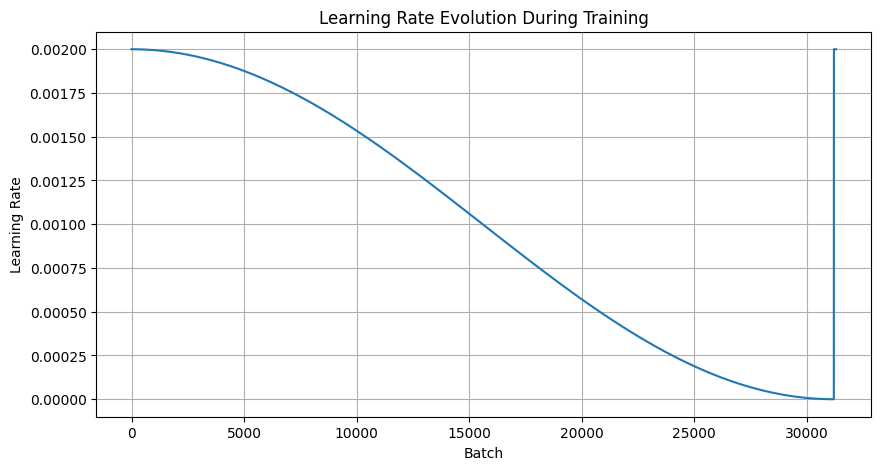


📊 Validation Results for Model GoMobileNet block_num=8, filters=32, factor=4 — Epoch 100:
  - loss                          : 3.2048
  - policy_loss                   : 2.4332
  - value_loss                    : 0.6969
  - policy_categorical_accuracy   : 0.3912
  - value_mse                     : 0.1222
  - Time: 2160.3505


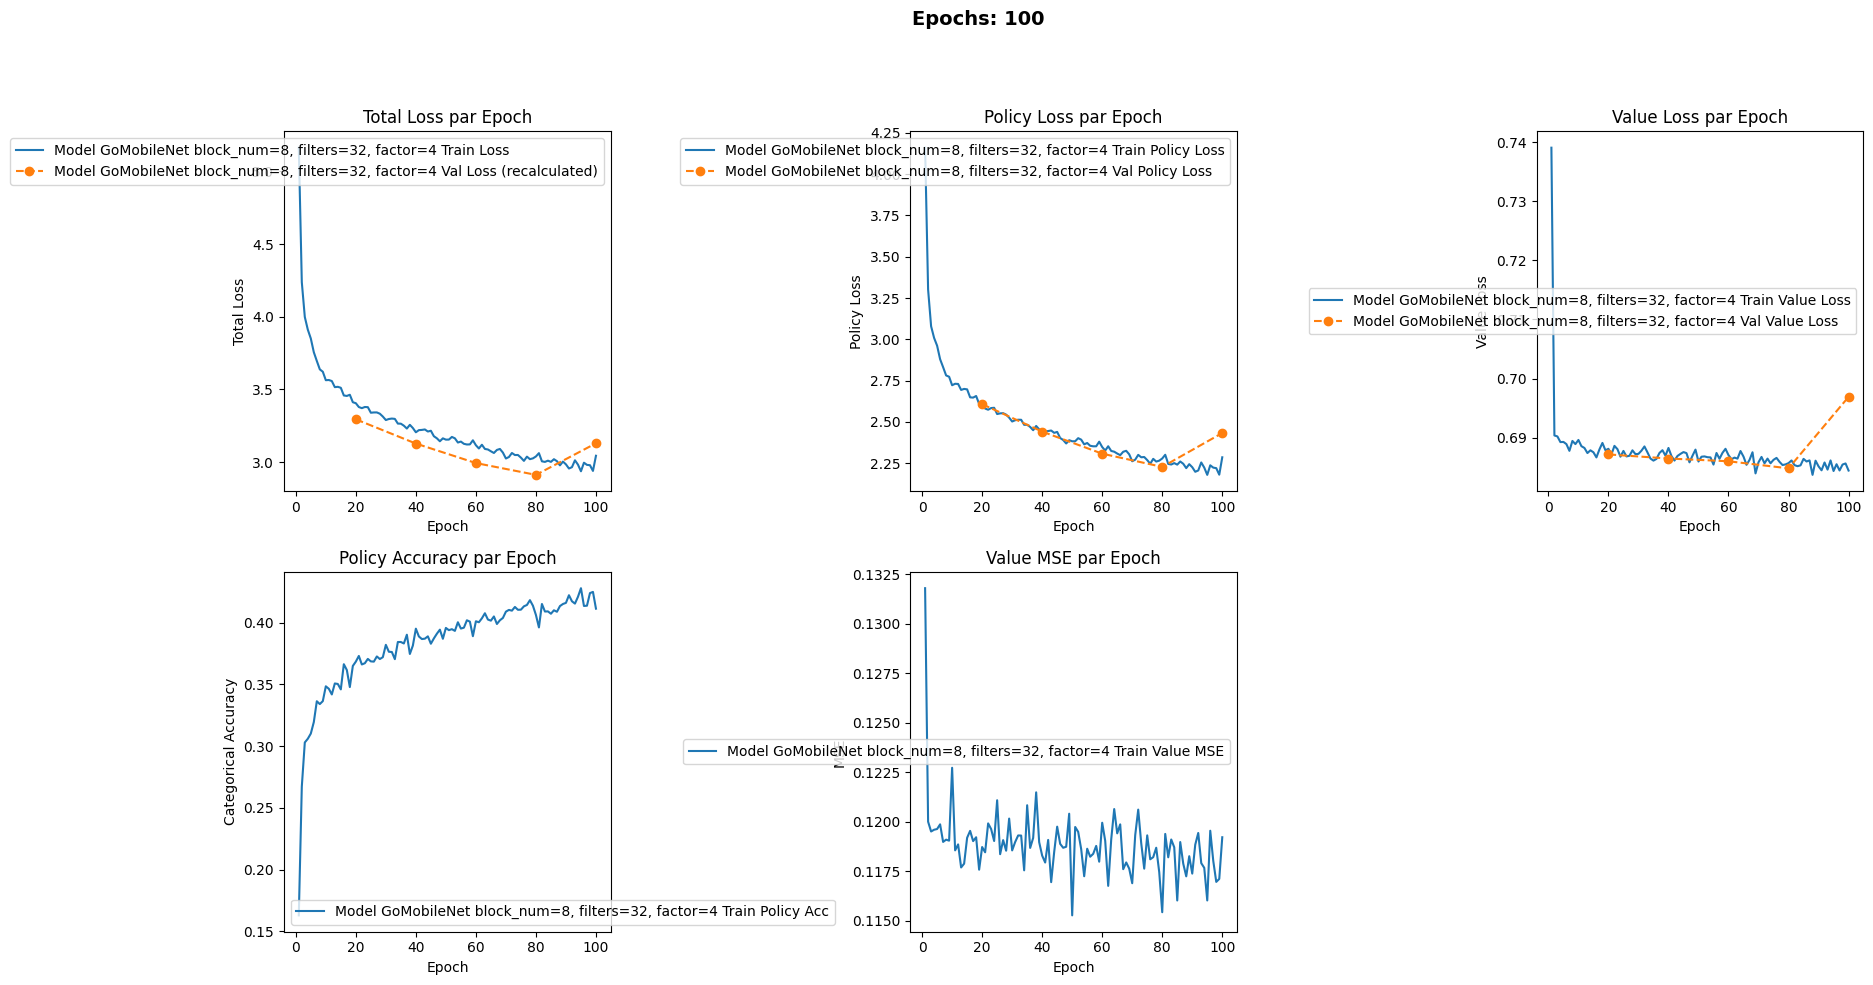

In [10]:
EPOCHS = 100

def test_gomobilenet(nb_cycle, epochs=EPOCHS):

    model = GoMobileNet((19, 19, 31), 361)
    model = model.build(block_num=8, filters=32, factor=4, se=True, drop_out_rate=0.2, activation='swish')
    model.summary()

    val, all_history, val_loss_history, total_time, lrs = train_model(
        model,
        batch=32,
        initial_lr=0.002,
        policy_weight=1.0,
        value_weight=1.0,
        epochs=epochs,
        N=10000,
        nb_cosinedecay_cycle=nb_cycle
    )
    return (f'Model GoMobileNet block_num=8, filters=32, factor=4'), model, val, all_history, val_loss_history, total_time, lrs


plot_version()

history = []
loss_history = []
titles = []
for nb_cycle in [1]:

    title, model, val, all_history, val_loss_history, total_time, lrs = test_gomobilenet(nb_cycle)
    plot_learning_rate(lrs)

    # Affichage des résultats
    results = [
        (model, val, title, total_time)
    ]
    print_validation_results(results, epoch=EPOCHS)

    history.append(all_history)
    loss_history.append(val_loss_history)
    titles.append(title)

# Affichage des courbes comparatives
plot_result(
    history_dfs=history,
    val_dfs=loss_history,
    labels=titles,
    epochs=EPOCHS
)